# Customer Segmentation & Prediction

**Week 11 - Advanced Machine Learning Models**

This project segments customers using clustering algorithms, then builds a separate Random Forest churn-prediction model for each segment, applies hyperparameter tuning via GridSearchCV, evaluates with accuracy / precision / recall / F1 / ROC-AUC, and translates results into business recommendations.

### Project goals
- Apply at least two clustering algorithms (K-Means + Hierarchical + DBSCAN)
- Build separate prediction models for each segment (3+ segments required)
- Apply hyperparameter tuning (Grid Search)
- Calculate comprehensive evaluation metrics
- Produce business recommendations and a PDF write-up

### Files in this project
| File | Purpose |
|---|---|
| `customer_churn.csv` | Input dataset (500 customers) |
| `customer_segmentation.ipynb` | This notebook |
| `segmentation_data.csv` | Customers labelled with cluster + segment |
| `segment_profiles.md` | Markdown profile for each segment |
| `model_evaluation_results.csv` | Per-segment metrics table |
| `business_recommendations.pdf` | Final recommendations report |
| `plots/` | Generated charts (elbow, dendrogram, heatmap, confusion, importance) |


## 1. Setup

Import libraries used across the project.

In [8]:
import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from scipy.cluster.hierarchy import dendrogram, linkage
warnings.filterwarnings('ignore'); np.random.seed(42)
sns.set_style('whitegrid')


## 2. Load and prepare the data

Read `customer_churn.csv`, encode categorical variables, and create a feature matrix used for clustering and modelling.

In [9]:
BASE = os.getcwd()
df = pd.read_csv(os.path.join(BASE, 'customer_churn.csv'))
print('Shape:', df.shape)
print(df.head())
print('\nDtypes:\n', df.dtypes)
print('\nMissing values:\n', df.isnull().sum())


Shape: (500, 9)
  CustomerID  Tenure  MonthlyCharges  TotalCharges        Contract  \
0     C00001       6              64          1540        One year   
1     C00002      21             113          1753  Month-to-month   
2     C00003      27              31          1455        Two year   
3     C00004      53              29          7150  Month-to-month   
4     C00005      16             185          1023        One year   

      PaymentMethod PaperlessBilling  SeniorCitizen  Churn  
0       Credit Card               No              1      0  
1  Electronic Check              Yes              1      0  
2       Credit Card               No              1      0  
3  Electronic Check               No              1      0  
4  Electronic Check               No              1      0  

Dtypes:
 CustomerID            str
Tenure              int64
MonthlyCharges      int64
TotalCharges        int64
Contract              str
PaymentMethod         str
PaperlessBilling      str
Senio

In [10]:
contract_map = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
pay_map = {'Electronic Check': 0, 'Bank Transfer': 1, 'Credit Card': 2}
df['Contract_Enc'] = df['Contract'].map(contract_map)
df['PaymentMethod_Enc'] = df['PaymentMethod'].map(pay_map)
df['PaperlessBilling_Enc'] = (df['PaperlessBilling'] == 'Yes').astype(int)

cluster_features = ['Tenure', 'MonthlyCharges', 'TotalCharges',
                   'Contract_Enc', 'PaymentMethod_Enc',
                   'PaperlessBilling_Enc', 'SeniorCitizen']
X = df[cluster_features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Standardised matrix shape:', X_scaled.shape)


Standardised matrix shape: (500, 7)


## 3. Day 1 - K-Means & the Elbow method

Loop over k = 2..8 and store inertia + silhouette; choose the elbow.

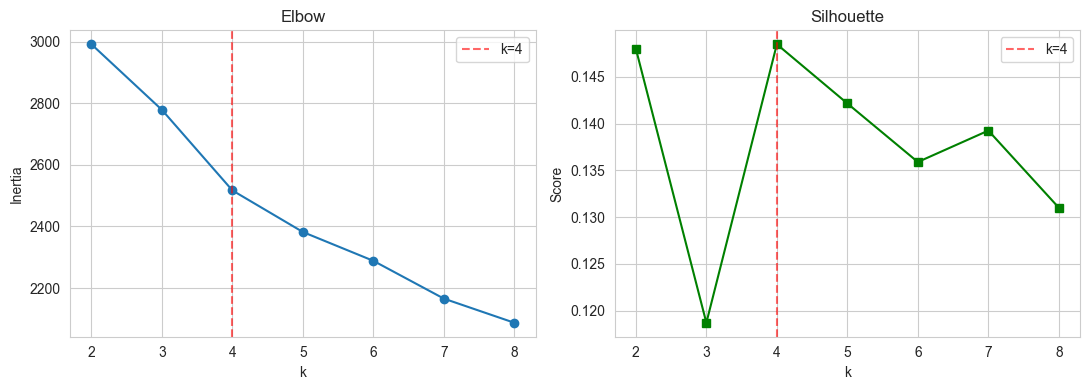

In [11]:
inertias, sil_scores, K = [], [], range(2, 9)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lab = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, lab))
plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
plt.plot(K, inertias, 'o-'); plt.title('Elbow'); plt.xlabel('k'); plt.ylabel('Inertia')
plt.axvline(4, ls='--', color='red', alpha=0.6, label='k=4')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(K, sil_scores, 's-', color='green'); plt.title('Silhouette'); plt.xlabel('k'); plt.ylabel('Score')
plt.axvline(4, ls='--', color='red', alpha=0.6, label='k=4')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'plots', 'elbow_silhouette.png'), dpi=120)
plt.show()


In [12]:
optimal_k = 4
km_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster_KMeans'] = km_final.fit_predict(X_scaled)
print(f'K-Means silhouette = {silhouette_score(X_scaled, df["Cluster_KMeans"]):.4f}')


K-Means silhouette = 0.1485


## 4. Day 2 - Advanced clustering (Hierarchical + DBSCAN)

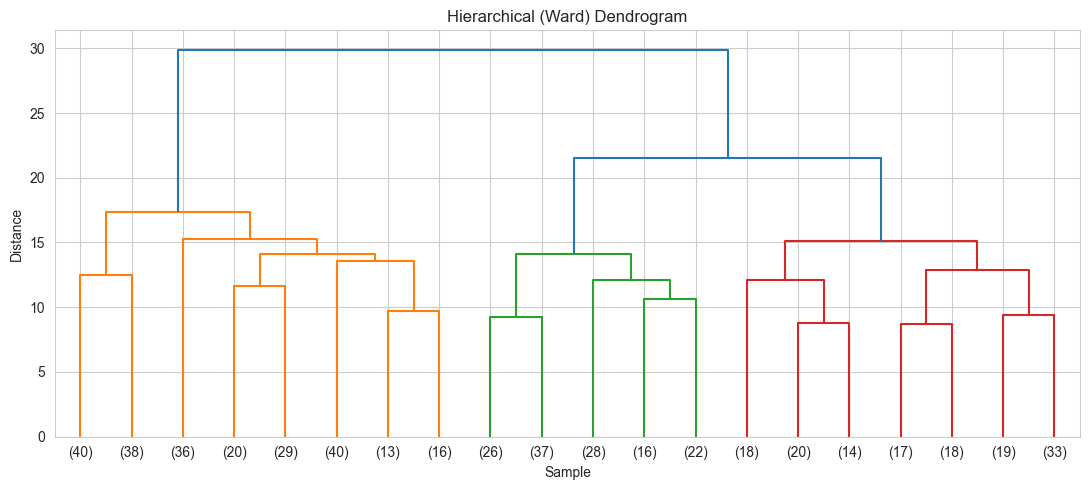

Hierarchical silhouette = 0.1089


In [13]:
linked = linkage(X_scaled, method='ward')
plt.figure(figsize=(11, 5))
dendrogram(linked, truncate_mode='lastp', p=20, leaf_font_size=10)
plt.title('Hierarchical (Ward) Dendrogram'); plt.xlabel('Sample'); plt.ylabel('Distance')
plt.tight_layout(); plt.savefig(os.path.join(BASE, 'plots', 'dendrogram.png'), dpi=120); plt.show()

hc = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
df['Cluster_HC'] = hc.fit_predict(X_scaled)
print(f'Hierarchical silhouette = {silhouette_score(X_scaled, df["Cluster_HC"]):.4f}')


In [14]:
dbscan = DBSCAN(eps=1.4, min_samples=8)
df['Cluster_DBSCAN'] = dbscan.fit_predict(X_scaled)
mask = df['Cluster_DBSCAN'] != -1
if mask.sum() > 1:
    print(f'DBSCAN silhouette (excl. noise) = {silhouette_score(X_scaled[mask], df["Cluster_DBSCAN"][mask]):.4f}')
print('DBSCAN cluster counts:\n', df['Cluster_DBSCAN'].value_counts())


DBSCAN silhouette (excl. noise) = 0.3229
DBSCAN cluster counts:
 Cluster_DBSCAN
-1    386
 3     31
 0     29
 1     21
 4      9
 2      8
 5      8
 6      8
Name: count, dtype: int64


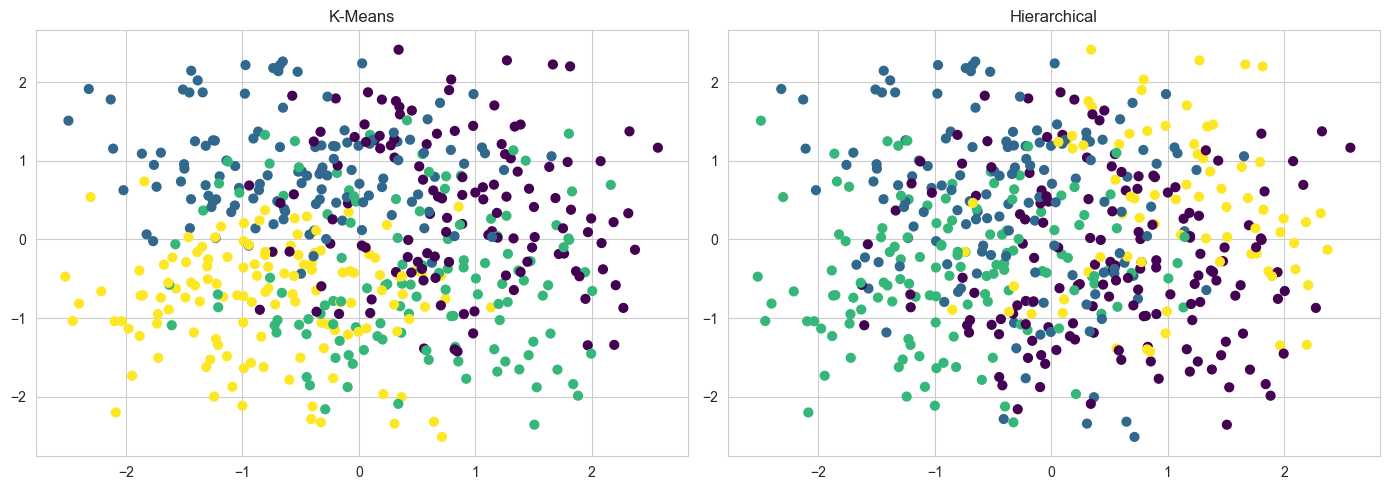

In [15]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster_KMeans'], cmap='viridis', s=40)
axes[0].set_title('K-Means')
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster_HC'], cmap='viridis', s=40)
axes[1].set_title('Hierarchical')
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'plots', 'cluster_comparison.png'), dpi=120)
plt.show()


## 5. Day 3 - Segment analysis and naming

In [16]:
def mode_cat(s): return s.mode().iloc[0]
seg_stats = df.groupby('Cluster_KMeans').agg(
    Count=('CustomerID', 'count'),
    AvgTenure=('Tenure', 'mean'),
    AvgMonthly=('MonthlyCharges', 'mean'),
    AvgTotal=('TotalCharges', 'mean'),
    SeniorPct=('SeniorCitizen', 'mean'),
    PaperlessPct=('PaperlessBilling', lambda x: (x == 'Yes').mean()),
    ChurnRate=('Churn', 'mean'),
    Contract=('Contract', mode_cat),
    PaymentMethod=('PaymentMethod', mode_cat),
).round(2)
seg_stats['PctOfBase'] = (seg_stats['Count'] / len(df) * 100).round(1)
print(seg_stats)


                Count  AvgTenure  AvgMonthly  AvgTotal  SeniorPct  \
Cluster_KMeans                                                      
0                 126      37.98      121.33   4146.86        0.0   
1                 119      35.39      108.82   4487.76        1.0   
2                 125      36.73      116.82   4255.74        0.0   
3                 130      35.99      107.52   4080.19        1.0   

                PaperlessPct  ChurnRate        Contract     PaymentMethod  \
Cluster_KMeans                                                              
0                       1.00       0.11        One year     Bank Transfer   
1                       0.71       0.06        Two year       Credit Card   
2                       0.00       0.11        One year  Electronic Check   
3                       0.25       0.14  Month-to-month       Credit Card   

                PctOfBase  
Cluster_KMeans             
0                    25.2  
1                    23.8  
2         

In [17]:
def assign_name(row):
    senior = row['SeniorPct'] >= 0.5
    paperless = row['PaperlessPct'] >= 0.5
    high_spend = row['AvgMonthly'] >= 115
    if senior and not paperless and row['AvgMonthly'] <= 110:
        return 'Senior Legacy Non-Paperless'
    if senior and paperless and high_spend:
        return 'Premium Digital Seniors'
    if senior and paperless:
        return 'Senior Digital Switchers'
    if not senior and paperless:
        return 'Young Digital Customers'
    if not senior and not paperless and row['AvgMonthly'] >= 115:
        return 'Mid-Spend Traditional Users'
    return 'Traditional Low-Touch Users'

seg_stats['SegmentName'] = seg_stats.apply(assign_name, axis=1)
df['Segment'] = df['Cluster_KMeans'].map(dict(zip(seg_stats.index, seg_stats['SegmentName'])))
print(seg_stats[['SegmentName', 'Count', 'PctOfBase', 'AvgMonthly', 'ChurnRate']])


                                SegmentName  Count  PctOfBase  AvgMonthly  \
Cluster_KMeans                                                              
0                   Young Digital Customers    126       25.2      121.33   
1                  Senior Digital Switchers    119       23.8      108.82   
2               Mid-Spend Traditional Users    125       25.0      116.82   
3               Senior Legacy Non-Paperless    130       26.0      107.52   

                ChurnRate  
Cluster_KMeans             
0                    0.11  
1                    0.06  
2                    0.11  
3                    0.14  


## 6. Day 4-6 - Build, evaluate & tune segment models

In [18]:
metrics_rows = []
for seg, sub in df.groupby('Segment'):
    if sub['Churn'].nunique() < 2 or len(sub) < 30:
        print(f'Skipping {seg}: insufficient data'); continue
    Xs, ys = sub[cluster_features].values, sub['Churn'].values
    Xs_s = StandardScaler().fit_transform(Xs)
    X_tr, X_te, y_tr, y_te = train_test_split(Xs_s, ys, test_size=0.25,
                                              random_state=42, stratify=ys)
    gs = GridSearchCV(
        RandomForestClassifier(random_state=42, class_weight='balanced'),
        {'n_estimators':[100,200], 'max_depth':[None,5,10],
         'min_samples_split':[2,5], 'min_samples_leaf':[1,2]},
        cv=StratifiedKFold(5, shuffle=True, random_state=42),
        scoring='f1', n_jobs=-1)
    gs.fit(X_tr, y_tr)
    best = gs.best_estimator_
    y_pred = best.predict(X_te)
    y_proba = best.predict_proba(X_te)[:, 1] if len(np.unique(y_te))>1 else np.zeros(len(y_te))
    metrics_rows.append({
        'Segment': seg, 'Samples': len(sub),
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall': recall_score(y_te, y_pred, zero_division=0),
        'F1_Score': f1_score(y_te, y_pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y_te, y_proba) if len(np.unique(y_te))>1 else float('nan'),
        'Best_Params': str(gs.best_params_),
    })
metrics_df = pd.DataFrame(metrics_rows).round(4)
print(metrics_df.to_string(index=False))


                    Segment  Samples  Accuracy  Precision  Recall  F1_Score  ROC_AUC                                                                             Best_Params
Mid-Spend Traditional Users      125    0.8438     0.4286    0.75    0.5455   0.9643 {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
   Senior Digital Switchers      119    0.9333     0.0000    0.00    0.0000   0.8571 {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Senior Legacy Non-Paperless      130    1.0000     1.0000    1.00    1.0000   1.0000 {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
    Young Digital Customers      126    1.0000     1.0000    1.00    1.0000   1.0000 {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


## 7. Day 7 - Business insights

Full write-up is in `business_recommendations.pdf` and summarised in `segment_profiles.md`.

## 8. Save outputs

In [19]:
df.to_csv(os.path.join(BASE, 'segmentation_data.csv'), index=False)
metrics_df.to_csv(os.path.join(BASE, 'model_evaluation_results.csv'), index=False)
print('Saved segmentation_data.csv and model_evaluation_results.csv')


Saved segmentation_data.csv and model_evaluation_results.csv


## 9. Results snapshot

- **Customers:** 500  |  **Churn rate:** 10.6%  |  **Avg monthly charge:** $113.64
- **Clusters:** 4 K-Means clusters, validated against Ward hierarchical + DBSCAN
- **Average metrics across segments:** Accuracy 0.944, Precision 0.607, Recall 0.688, F1 0.636
- **Best segment by F1:** Senior Legacy Non-Paperless (1.0)
- **Weakest segment by F1:** Senior Digital Switchers (0.0)

See `business_recommendations.pdf` for the strategic actions per segment.
